In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
plt.rcParams.update({
    "axes.labelsize": 12,     
    "axes.titlesize": 14, 
    "xtick.labelsize": 12,
    "ytick.labelsize": 12, 
    "legend.fontsize": 8,
})

l2_norm_by_dim


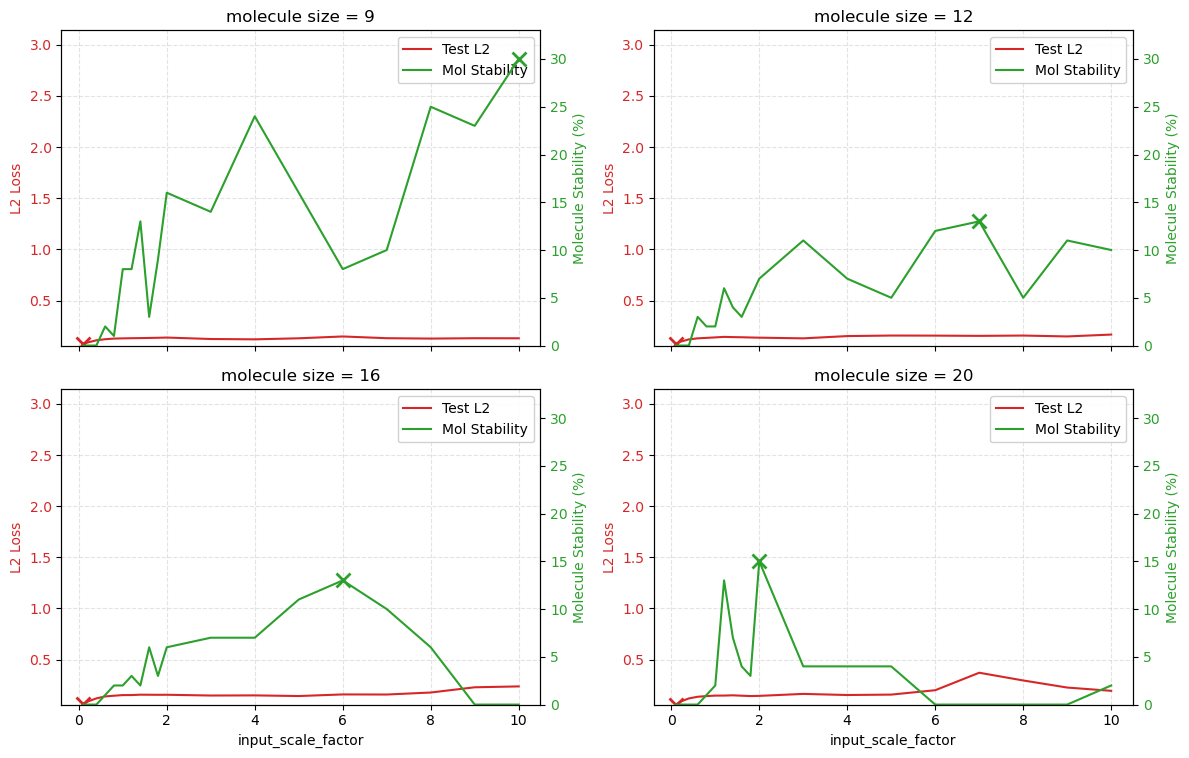

l2_norm_by_num_atoms


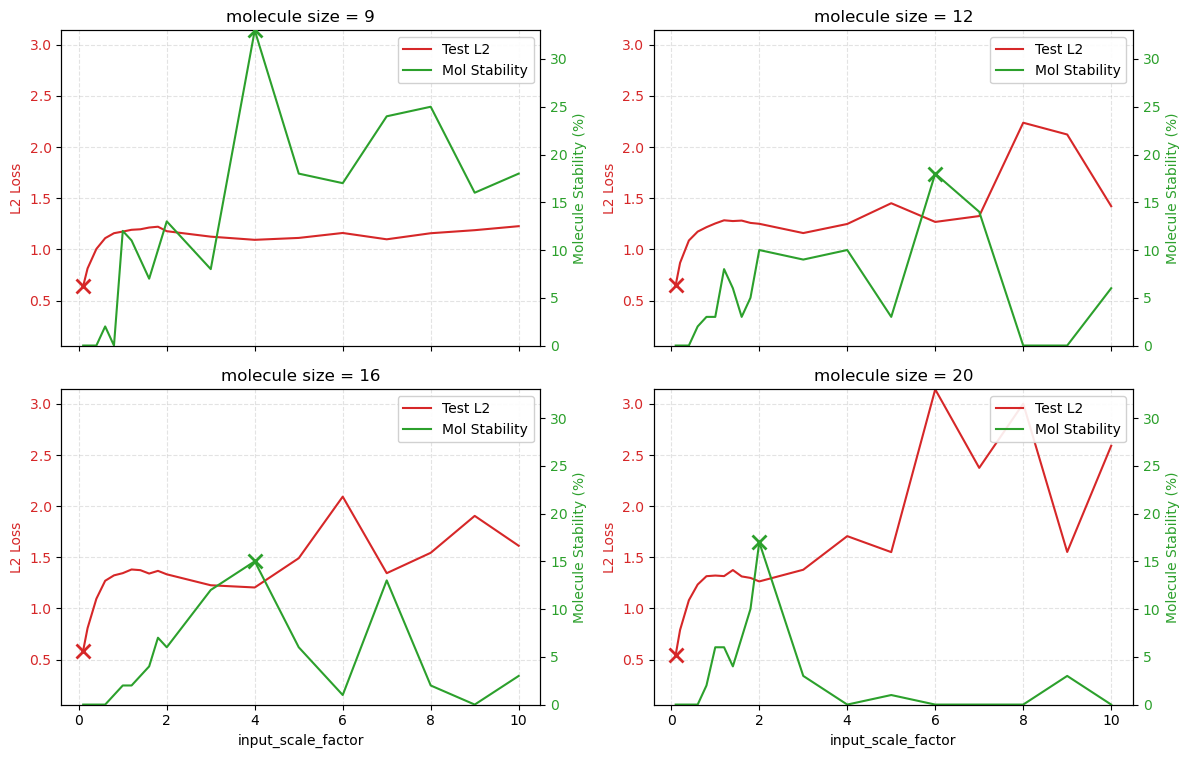

In [17]:
df = pd.read_csv("input_scaling_evaluation_log_rq2.csv")

grouped = (
    df.groupby(
        ["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule", "diffusion_loss_type"], dropna=False,
    ).agg({"mol_stable": "mean", "test_l2": "mean"})
    .reset_index()
)

filter_values = sorted(grouped["filter_n_atoms"].dropna().unique()) 

mol_min, mol_max = grouped["mol_stable"].min(), grouped["mol_stable"].max()
test_min, test_max = grouped["test_l2"].min(), grouped["test_l2"].max()

for loss_value, loss_df in grouped.groupby("diffusion_loss_type"):
    print(loss_value)
    sub_df = grouped[grouped["diffusion_loss_type"] == loss_value].copy()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, n_atoms in enumerate(filter_values):
        ax_left = axes[i]
        sub_df = loss_df[loss_df["filter_n_atoms"] == n_atoms].copy()
        sub_df = sub_df.sort_values("input_scale_factor").reset_index(drop=True)
        x = sub_df["input_scale_factor"].to_numpy()
        y_test = sub_df["test_l2"].to_numpy()
        y_mol = sub_df["mol_stable"].to_numpy()

        color_left = "tab:red"
        ax_left.plot(x, y_test, linestyle='-', color=color_left, label="Test L2")
        ax_left.set_ylabel("L2 Loss", color=color_left)
        ax_left.tick_params(axis='y', labelcolor=color_left)
        ax_left.set_ylim(test_min, test_max)
        ax_left.set_title(f"molecule size = {n_atoms}")
        ax_left.grid(True, linestyle='--', alpha=0.35)
        idx_test_min = int(np.nanargmin(y_test))
        ax_left.plot(x[idx_test_min], y_test[idx_test_min], marker='x', markersize=10, markeredgewidth=2,
                    color=color_left, zorder=10, label="Min L2 Loss")

        ax_right = ax_left.twinx()
        color_right = "tab:green"
        ax_right.plot(x, y_mol, linestyle='-', color=color_right, label="Molecule Stability (%)")
        ax_right.set_ylabel("Molecule Stability (%)", color=color_right)
        ax_right.tick_params(axis='y', labelcolor=color_right)
        ax_right.set_ylim(mol_min, mol_max)

        idx_mol_max = int(np.nanargmax(y_mol))
        ax_right.plot(x[idx_mol_max], y_mol[idx_mol_max], marker='x', markersize=10, markeredgewidth=2,
                      color=color_right, zorder=10, label="Max mol_stable")

        if i >= 2:
            ax_left.set_xlabel("input_scale_factor")

        handles = [
            Line2D([0], [0], color=color_left, label="Test L2"),
            Line2D([0], [0], color=color_right, label="Mol Stability"),
        ]
        ax_left.legend(handles=handles, loc="upper right", framealpha=0.9)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
